# Лабораторная работа №5 — Ансамбли моделей (часть 1)

## Цель
Обучить и сравнить ансамблевые модели: бэггинг, случайный лес, AdaBoost, Gradient Boosting.


In [1]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

dataset_path = PROJECT_ROOT / 'courses_current' / 'notebooks' / 'features' / 'data' / 'titanic.csv'
df = pd.read_csv(dataset_path)
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']


In [2]:
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

models = {
    'Bagging(DecisionTree)': BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}


## 1. Обучение ансамблей и оценка качества


In [3]:
rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'f1': f1_score(y_test, pred),
    })

res = pd.DataFrame(rows).sort_values('f1', ascending=False)
display(res)


,model,accuracy,f1
2,AdaBoost,0.780269,0.716763
3,GradientBoosting,0.798206,0.701987
1,RandomForest,0.789238,0.688742
0,Bagging(DecisionTree),0.798206,0.680851


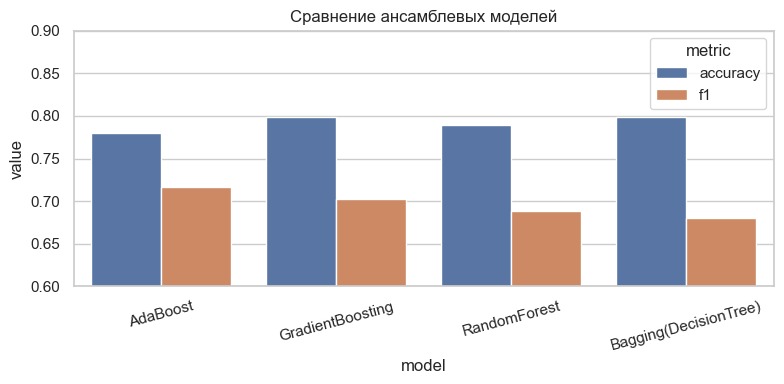

<Figure size 640x480 with 0 Axes>

In [4]:
plot_df = res.melt(id_vars='model', value_vars=['accuracy', 'f1'], var_name='metric', value_name='value')
plt.figure(figsize=(8,4))
sns.barplot(data=plot_df, x='model', y='value', hue='metric')
plt.ylim(0.6, 0.9)
plt.xticks(rotation=15)
plt.title('Сравнение ансамблевых моделей')
plt.tight_layout()
plt.show()
plt.savefig(ART / 'ensembles_comparison.png', dpi=170, bbox_inches='tight')

res.to_json(ART / 'metrics.json', orient='records', force_ascii=False, indent=2)


## Выводы
- Все ансамбли дали сопоставимое качество, различаясь по метрике F1.
- Для практики имеет смысл выбирать модель по балансу качества и интерпретируемости/скорости.
